# MBRA Labeleing for Sample Files

This file pulls in a small zip file from the frodobots-2k dataset and relabels it with action labels using the MBRA model.

## 1. Install dependencies 


In [ ]:
# Colab only. torch/torchvision/numpy/pandas/Pillow/tqdm/matplotlib ship with Colab
# already, and so does the ffmpeg binary -- we only need a couple of extra packages.
!pip install -q "efficientnet-pytorch==0.7.1" "huggingface_hub>=0.24" pyyaml

import subprocess
assert subprocess.run(["ffmpeg", "-version"], capture_output=True).returncode == 0, (
    "ffmpeg not found -- expected to be preinstalled on Colab"
)
print("Dependencies OK.")


  Preparing metadata (setup.py) ... done
Dependencies OK.


## 2. Mount Drive, get the code, and set up paths

Raw per-ride files pulled from the dataset (CSVs + video) and the final MBRA label
CSVs are persisted to a Drive folder so they survive a runtime restart. Decoded
JPEG frames are *not* persisted to Drive -- they're bulky and fully reproducible
from the downloaded video, so they live only on the Colab VM's local disk.

In [ ]:
import os

from google.colab import drive
drive.mount("/content/drive")

REPO_URL = "https://github.com/vaishnavi-suresh/Learning-to-Drive-Anywhere-with-MBRA.git"
REPO_DIR = "/content/Learning-to-Drive-Anywhere-with-MBRA"

if not os.path.exists(REPO_DIR):
    !git clone -q {REPO_URL} {REPO_DIR}

import sys
sys.path.insert(0, os.path.join(REPO_DIR, "train"))

DRIVE_ROOT = "/content/drive/MyDrive/MBRA_reannotate"
INPUTS_DIR = os.path.join(DRIVE_ROOT, "inputs")     # raw per-ride CSVs + video, pulled from the dataset zip
OUTPUTS_DIR = os.path.join(DRIVE_ROOT, "outputs")   # predicted action-label CSVs
LOCAL_FRAMES_DIR = "/content/frames"                # decoded JPEGs -- local disk only, not persisted to Drive

os.makedirs(INPUTS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(LOCAL_FRAMES_DIR, exist_ok=True)

print("Drive inputs:", INPUTS_DIR)
print("Drive outputs:", OUTPUTS_DIR)
print("Local frames (ephemeral):", LOCAL_FRAMES_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive inputs: /content/drive/MyDrive/MBRA_reannotate/inputs
Drive outputs: /content/drive/MyDrive/MBRA_reannotate/outputs
Local frames (ephemeral): /content/frames


## 3. Configuration

`CONTEXT_SIZE` and `LEN_TRAJ_PRED` are baked into the `mbra.pth` checkpoint's
weight shapes (positional encoding + final linear layers) -- changing them
will silently produce garbage predictions because the pretrained weights for
those layers won't load. `GOAL_HORIZON`, `ROBOT_SIZE`, `DELAY`, and the
`VEL_PAST_*` values are just runtime inputs to the (fixed) model, so they're
safe to tweak. The `GOAL_HORIZON`/robot-size/delay/velocity defaults below
match how `train_MBRA`/`train_LogoNav` in `train_utils.py` call this model.

In [ ]:
# --- Dataset ---
DATASET_URL = "https://frodobots-2k-dataset.s3.ap-southeast-1.amazonaws.com/output_rides_0.zip"
NUM_SAMPLE_RIDES = 10  # how many rides to pull from the zip; raise this to label more data

# --- MBRA architecture (fixed by the checkpoint -- do not change without retraining) ---
CONTEXT_SIZE = 5      # number of history frames stacked with the current frame
LEN_TRAJ_PRED = 8     # length of the predicted action trajectory

# --- MBRA inference-time scenario inputs (safe to tweak/experiment with) ---
GOAL_HORIZON = 30        # frames ahead (front camera runs at ~20Hz) used as the "goal" image, ~1.5s
ROBOT_SIZE = 0.3         # assumed robot radius in meters
DELAY = 0.0              # assumed control delay in seconds
VEL_PAST_LINEAR = 0.5    # assumed prior linear velocity in m/s ("was going straight")
VEL_PAST_ANGULAR = 0.0   # assumed prior angular velocity in rad/s

IMAGE_SIZE = (96, 96)    # matches MBRA.yaml's image_size

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 4. Find a sample of rides and pull down their raw files

`output_rides_23.zip` is ~2.1GB and holds 53 rides. Each ride folder has
`control_data`/`gps_data`/`imu_data`/`*_camera_timestamps` CSVs plus a
`recordings/` folder of HLS video segments (`.ts` files) -- there are no
plain JPEGs, so the front-camera frames have to be decoded from video later.

Rather than downloading the whole zip to grab a small sample, we read just
the ZIP central directory over HTTP range requests to see what's inside,
then download only the CSVs and (non-audio) video segments for the rides we
actually want, again via range requests into the compressed bytes of each
member.

In [ ]:
import struct
import zlib
from collections import defaultdict

import requests


def _fetch_range(url, start, end):
    r = requests.get(url, headers={"Range": f"bytes={start}-{end}"})
    r.raise_for_status()
    return r.content


def _resolve_zip64_fields(extra, usize, csize, local_offset):
    """A central-directory record only gets a zip64 extra field (id 0x0001) when at
    least one of its usize/csize/local_offset didn't fit in 32 bits (sentinel
    0xFFFFFFFF); the extra field then carries the true 64-bit values for exactly
    those sentinelled fields, in usize/csize/local_offset order."""
    off = 0
    while off + 4 <= len(extra):
        tag, size = struct.unpack("<HH", extra[off:off + 4])
        data = extra[off + 4:off + 4 + size]
        if tag == 0x0001:
            p = 0
            if usize == 0xFFFFFFFF:
                (usize,) = struct.unpack_from("<Q", data, p); p += 8
            if csize == 0xFFFFFFFF:
                (csize,) = struct.unpack_from("<Q", data, p); p += 8
            if local_offset == 0xFFFFFFFF:
                (local_offset,) = struct.unpack_from("<Q", data, p); p += 8
            break
        off += 4 + size
    return usize, csize, local_offset


def list_zip_entries(url):
    """Reads just the ZIP end-of-central-directory + central directory over HTTP
    range requests, so we can see every filename in the archive without
    downloading it in full (some of these dataset zips are 20GB+)."""
    total = int(requests.head(url).headers["Content-Length"])
    tail = _fetch_range(url, max(0, total - 65536), total - 1)
    eocd_idx = tail.rfind(b"PK\x05\x06")
    (_, _, _, _, total_entries, cd_size, cd_offset, _) = struct.unpack(
        "<IHHHHIIH", tail[eocd_idx:eocd_idx + 22]
    )
    if cd_offset == 0xFFFFFFFF:  # ZIP64 (archive > 4GB): real offset/size/count live in a separate record
        locator_idx = tail.rfind(b"PK\x06\x07")
        (_, zip64_eocd_offset, _) = struct.unpack("<IQI", tail[locator_idx + 4:locator_idx + 20])
        zip64_eocd = _fetch_range(url, zip64_eocd_offset, zip64_eocd_offset + 55)
        assert zip64_eocd[:4] == b"PK\x06\x06", "bad zip64 end-of-central-directory record"
        (_, _, _, _, _, _, total_entries, cd_size, cd_offset) = struct.unpack(
            "<QHHIIQQQQ", zip64_eocd[4:56]
        )
    cd = _fetch_range(url, cd_offset, cd_offset + cd_size - 1)

    entries, offset = [], 0
    while offset + 4 <= len(cd) and cd[offset:offset + 4] == b"PK\x01\x02":
        fixed = cd[offset + 4:offset + 46]
        (_, _, _, method, _, _, _, csize, usize, n_len, extra_len, comment_len,
         _, _, _, local_offset) = struct.unpack("<HHHHHHIIIHHHHHII", fixed)
        name = cd[offset + 46:offset + 46 + n_len].decode("utf-8", errors="replace")
        extra = cd[offset + 46 + n_len:offset + 46 + n_len + extra_len]
        if 0xFFFFFFFF in (usize, csize, local_offset):
            usize, csize, local_offset = _resolve_zip64_fields(extra, usize, csize, local_offset)
        entries.append({"name": name, "method": method, "csize": csize,
                         "usize": usize, "local_offset": local_offset})
        offset += 46 + n_len + extra_len + comment_len
    assert len(entries) == total_entries, f"expected {total_entries} entries, parsed {len(entries)}"
    return entries


def download_zip_entry(url, entry, header_buffer=512):
    """Downloads and decompresses a single member of the remote ZIP via a range
    request into just its (compressed) bytes, without touching the rest of the archive."""
    start = entry["local_offset"]
    buf = _fetch_range(url, start, start + 30 + header_buffer + entry["csize"] - 1)
    assert buf[:4] == b"PK\x03\x04", "bad local file header"
    (_, _, method, _, _, _, _, _, n_len, extra_len) = struct.unpack("<HHHHHIIIHH", buf[4:30])
    data_start = 30 + n_len + extra_len
    raw = buf[data_start:data_start + entry["csize"]]
    if len(raw) < entry["csize"]:  # local extra field was bigger than our guess -- refetch with headroom
        buf = _fetch_range(url, start, start + data_start + entry["csize"] - 1)
        raw = buf[data_start:data_start + entry["csize"]]
    return zlib.decompress(raw, -15) if method == 8 else raw


def group_entries_by_ride(entries):
    rides = defaultdict(list)
    for e in entries:
        parts = e["name"].split("/")
        if len(parts) >= 2 and parts[1].startswith("ride_"):
            rides[parts[1]].append(e)
    return rides


def select_ride_files(ride_entries):
    """Keep the CSVs plus front/rear video segments; skip audio-only segments
    and .m3u8 playlists we don't need since we concatenate .ts segments directly."""
    keep = []
    for e in ride_entries:
        if e["name"].endswith("/"):
            continue
        base = e["name"].rsplit("/", 1)[-1]
        if base.startswith(("control_data", "front_camera_timestamps", "gps_data")):
            keep.append(e)
        elif "/recordings/" in e["name"] and base.endswith(".ts") and "_audio_" not in base:
            keep.append(e)
    return keep


def download_ride(ride_id, ride_entries, dest_root):
    dest_dir = os.path.join(dest_root, ride_id)
    for e in select_ride_files(ride_entries):
        rel_path = e["name"].split(f"{ride_id}/", 1)[1]
        out_path = os.path.join(dest_dir, rel_path)
        if os.path.exists(out_path) and os.path.getsize(out_path) == e["usize"]:
            continue  # already downloaded on a previous run of this notebook
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        with open(out_path, "wb") as f:
            f.write(download_zip_entry(DATASET_URL, e))
    return dest_dir


entries = list_zip_entries(DATASET_URL)
rides = group_entries_by_ride(entries)
all_ride_ids = sorted(rides.keys())
print(f"{len(all_ride_ids)} rides found in {DATASET_URL}")

selected_ride_ids = all_ride_ids[:NUM_SAMPLE_RIDES]
print("Selected sample:", selected_ride_ids)

ride_local_dirs = {}
for ride_id in selected_ride_ids:
    print("Downloading", ride_id, "...")
    ride_local_dirs[ride_id] = download_ride(ride_id, rides[ride_id], INPUTS_DIR)
print("Done. Raw inputs saved under", INPUTS_DIR)

231 rides found in https://frodobots-2k-dataset.s3.ap-southeast-1.amazonaws.com/output_rides_0.zip
Selected sample: ['ride_16446_20240115041752', 'ride_16448_20240115042257', 'ride_16449_20240115042645', 'ride_16450_20240115043352', 'ride_16460_20240115060734', 'ride_16461_20240115061052', 'ride_16462_20240115061436', 'ride_16466_20240115063035', 'ride_16470_20240115063715', 'ride_16471_20240115064734']
Done. Raw inputs saved under /content/drive/MyDrive/MBRA_reannotate/inputs


## 5. Decode the front-camera HLS video into frames

Each ride has two video streams under `recordings/` (`uid_s_<id>__uid_e_video`),
but nothing in the filenames says which one is the front camera. For each
stream we concatenate its `.ts` segments (valid for MPEG-TS/HLS) and decode
with `ffmpeg`, then keep whichever stream's frame count best matches the
ride's `front_camera_timestamps_*.csv` row count -- that's our front-camera
heuristic. The losing stream's frames are deleted immediately to save local
disk. Decoded frames are written to `LOCAL_FRAMES_DIR` only (not Drive).

In [5]:
import glob
import re
import shutil
import subprocess

import pandas as pd


def concat_and_decode(ts_paths, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    combined_path = os.path.join(out_dir, "_combined.ts")
    with open(combined_path, "wb") as out_f:
        for p in sorted(ts_paths):  # segment filenames end in a fixed-width timestamp, so lexical sort == chronological
            with open(p, "rb") as in_f:
                shutil.copyfileobj(in_f, out_f)
    # No -fps_mode/-vsync flag: the image2 (JPEG sequence) muxer already writes
    # one file per decoded frame with no timestamp-driven drop/duplicate logic,
    # so passthrough is the default here. This also sidesteps -fps_mode not
    # existing on older ffmpeg builds (it replaced -vsync in ffmpeg 5.1; some
    # Colab images still ship an older ffmpeg where the flag we used to pass
    # would be rejected outright).
    result = subprocess.run(
        ["ffmpeg", "-y", "-loglevel", "error", "-i", combined_path,
         "-q:v", "3", os.path.join(out_dir, "frame_%06d.jpg")],
        capture_output=True, text=True,
    )
    if result.returncode != 0:
        raise RuntimeError(f"ffmpeg failed decoding {combined_path}:\n{result.stderr}")
    os.remove(combined_path)
    return sorted(glob.glob(os.path.join(out_dir, "frame_*.jpg")))


def decode_front_camera(ride_id, ride_dir, local_frames_root):
    ts_by_stream = defaultdict(list)
    for p in glob.glob(os.path.join(ride_dir, "recordings", "*.ts")):
        m = re.search(r"uid_s_(\d+)__uid_e_video", os.path.basename(p))
        if m:
            ts_by_stream[m.group(1)].append(p)

    front_ts_csv = glob.glob(os.path.join(ride_dir, "front_camera_timestamps_*.csv"))
    expected_frames = len(pd.read_csv(front_ts_csv[0])) if front_ts_csv else None

    best_stream, best_frames, best_diff = None, [], float("inf")
    for stream_id, ts_paths in ts_by_stream.items():
        out_dir = os.path.join(local_frames_root, ride_id, f"stream_{stream_id}")
        frames = concat_and_decode(ts_paths, out_dir)
        # if we don't know the expected count, prefer the stream with more frames
        diff = abs(len(frames) - expected_frames) if expected_frames is not None else -len(frames)
        print(f"    stream {stream_id}: {len(frames)} frames "
              f"(front_camera_timestamps.csv has {expected_frames})")
        if diff < best_diff:
            if best_stream is not None:
                shutil.rmtree(os.path.join(local_frames_root, ride_id, f"stream_{best_stream}"), ignore_errors=True)
            best_stream, best_frames, best_diff = stream_id, frames, diff
        else:
            shutil.rmtree(out_dir, ignore_errors=True)

    print(f"    -> using stream {best_stream} as the front camera for {ride_id}")
    return best_frames


front_frames_by_ride = {}
for ride_id, ride_dir in ride_local_dirs.items():
    print("Decoding", ride_id)
    front_frames_by_ride[ride_id] = decode_front_camera(ride_id, ride_dir, LOCAL_FRAMES_DIR)

Decoding ride_16446_20240115041752
    stream 1000: 2567 frames (front_camera_timestamps.csv has 2567)
    stream 1001: 2587 frames (front_camera_timestamps.csv has 2567)
    -> using stream 1000 as the front camera for ride_16446_20240115041752
Decoding ride_16448_20240115042257


KeyboardInterrupt: 

## 6. Load the MBRA model

MBRA is an `ExAug_dist_delay` model (see `train/vint_train/models/exaug/exaug.py`),
configured by `train/config/MBRA.yaml` and loaded the same way `train.py` loads
it for reannotation: `state_dict = torch.load(mbra.pth); model.load_state_dict(state_dict, strict=False)`.

`deployment/mbra.pth` isn't committed to this git repo (it's a 394MB binary),
so it's fetched from the `NHirose/MBRA_project_models` Hugging Face repo it was
originally published to, and copied to `deployment/mbra.pth` inside the cloned
repo to match the path used elsewhere in this project.

In [ ]:
import yaml
from huggingface_hub import hf_hub_download

from vint_train.models.exaug.exaug import ExAug_dist_delay

with open(os.path.join(REPO_DIR, "train", "config", "MBRA.yaml")) as f:
    mbra_config = yaml.safe_load(f)

assert mbra_config["context_size"] == CONTEXT_SIZE
assert mbra_config["len_traj_pred"] == LEN_TRAJ_PRED

model = ExAug_dist_delay(
    context_size=mbra_config["context_size"],
    len_traj_pred=mbra_config["len_traj_pred"],
    learn_angle=mbra_config["learn_angle"],
    obs_encoder=mbra_config["obs_encoder"],
    obs_encoding_size=mbra_config["obs_encoding_size"],
    late_fusion=mbra_config["late_fusion"],
    mha_num_attention_heads=mbra_config["mha_num_attention_heads"],
    mha_num_attention_layers=mbra_config["mha_num_attention_layers"],
    mha_ff_dim_factor=mbra_config["mha_ff_dim_factor"],
)

weights_path = os.path.join(REPO_DIR, "deployment", "mbra.pth")
if not os.path.exists(weights_path):
    os.makedirs(os.path.dirname(weights_path), exist_ok=True)
    downloaded = hf_hub_download(repo_id="NHirose/MBRA_project_models", filename="mbra.pth")
    shutil.copy(downloaded, weights_path)

state_dict = torch.load(weights_path, map_location=device)
missing, unexpected = model.load_state_dict(state_dict, strict=False)
assert not missing, f"missing keys when loading mbra.pth: {missing}"
model.eval().to(device)
print("Loaded MBRA weights from", weights_path)

/content/Learning-to-Drive-Anywhere-with-MBRA/train/vint_train/models/vint/self_attention.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.sa_decoder = nn.TransformerEncoder(self.sa_layer, num_layers=num_layers)


Loaded MBRA weights from /content/Learning-to-Drive-Anywhere-with-MBRA/deployment/mbra.pth


## 7. Run MBRA over every frame and save the predicted action labels to Drive

For frame `t`, MBRA takes: the current frame plus `CONTEXT_SIZE` frames of
history (channel-concatenated, oldest -> newest), a single "goal" frame
`GOAL_HORIZON` frames ahead, and the fixed robot-size/delay/past-velocity
scenario tensors -- exactly the five arguments `ExAug_dist_delay.forward`
takes. It returns an 8-step `(linear_vel, angular_vel)` trajectory and a
predicted distance. We save the first step of each trajectory plus the full
trajectory, and merge in the ride's original human-driven `control_data` (by
nearest timestamp) so the reannotated labels can be compared to what the
human operator actually did.

In [ ]:
from PIL import Image
from torchvision import transforms
from tqdm.auto import tqdm

frame_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def load_frame_tensor(path):
    return frame_transform(Image.open(path).convert("RGB"))  # [3, H, W]


def build_obs_tensor(frame_paths, t, context_size):
    imgs = [load_frame_tensor(frame_paths[i]) for i in range(t - context_size, t + 1)]
    return torch.cat(imgs, dim=0).unsqueeze(0)  # [1, 3*(context_size+1), H, W]


def build_goal_tensor(frame_paths, t, goal_horizon):
    return load_frame_tensor(frame_paths[t + goal_horizon]).unsqueeze(0)  # [1, 3, H, W]


robot_size = ROBOT_SIZE * torch.ones(1, 1, 1, device=device)
delay = DELAY * torch.ones(1, 1, 1, device=device)
vel_past = torch.cat([
    VEL_PAST_LINEAR * torch.ones(1, 6),
    VEL_PAST_ANGULAR * torch.ones(1, 6),
], dim=1).unsqueeze(2).to(device)  # [1, 12, 1]


def load_control_data(ride_dir):
    return pd.read_csv(glob.glob(os.path.join(ride_dir, "control_data_*.csv"))[0]).sort_values("timestamp")


def load_front_timestamps(ride_dir):
    return pd.read_csv(glob.glob(os.path.join(ride_dir, "front_camera_timestamps_*.csv"))[0]).sort_values("timestamp")


results_by_ride = {}
for ride_id in selected_ride_ids:
    frame_paths = front_frames_by_ride[ride_id]
    front_ts = load_front_timestamps(ride_local_dirs[ride_id])
    n_frames = min(len(frame_paths), len(front_ts))
    if n_frames <= CONTEXT_SIZE + GOAL_HORIZON:
        print(f"Skipping {ride_id}: only {n_frames} decoded frames, need > {CONTEXT_SIZE + GOAL_HORIZON}")
        continue

    rows = []
    for t in tqdm(range(CONTEXT_SIZE, n_frames - GOAL_HORIZON), desc=ride_id):
        obs = build_obs_tensor(frame_paths, t, CONTEXT_SIZE).to(device)
        goal = build_goal_tensor(frame_paths, t, GOAL_HORIZON).to(device)
        with torch.no_grad():
            linear_vel, angular_vel, dist_pred = model(obs, goal, robot_size, delay, vel_past)
        rows.append({
            "frame_id": t,
            "timestamp": float(front_ts.iloc[t]["timestamp"]),
            "mbra_linear_vel_mps": linear_vel[0, 0].item(),
            "mbra_angular_vel_radps": angular_vel[0, 0].item(),
            "mbra_linear_vel_traj": linear_vel[0].tolist(),
            "mbra_angular_vel_traj": angular_vel[0].tolist(),
            "mbra_dist_pred": dist_pred[0, 0].item(),
        })
    df = pd.DataFrame(rows)

    control = load_control_data(ride_local_dirs[ride_id])[["linear", "angular", "timestamp"]]
    df = pd.merge_asof(
        df.sort_values("timestamp"), control, on="timestamp", direction="nearest",
    ).rename(columns={"linear": "orig_linear_vel_mps", "angular": "orig_angular_vel_radps"})

    out_path = os.path.join(OUTPUTS_DIR, f"{ride_id}_mbra_labels.csv")
    df.to_csv(out_path, index=False)
    results_by_ride[ride_id] = df
    print(f"Saved {len(df)} labeled frames for {ride_id} -> {out_path}")

ride_16446_20240115041752:   0%|          | 0/2532 [00:00<?, ?it/s]

Saved 2532 labeled frames for ride_16446_20240115041752 -> /content/drive/MyDrive/MBRA_reannotate/outputs/ride_16446_20240115041752_mbra_labels.csv


ride_16448_20240115042257:   0%|          | 0/3704 [00:00<?, ?it/s]

Saved 3704 labeled frames for ride_16448_20240115042257 -> /content/drive/MyDrive/MBRA_reannotate/outputs/ride_16448_20240115042257_mbra_labels.csv


ride_16449_20240115042645:   0%|          | 0/7300 [00:00<?, ?it/s]

...

Saved 7516 labeled frames for ride_16466_20240115063035 -> /content/drive/MyDrive/MBRA_reannotate/outputs/ride_16466_20240115063035_mbra_labels.csv


ride_16470_20240115063715:   0%|          | 0/955 [00:00<?, ?it/s]

Saved 955 labeled frames for ride_16470_20240115063715 -> /content/drive/MyDrive/MBRA_reannotate/outputs/ride_16470_20240115063715_mbra_labels.csv


ride_16471_20240115064734:   0%|          | 0/13609 [00:00<?, ?it/s]

Saved 13609 labeled frames for ride_16471_20240115064734 -> /content/drive/MyDrive/MBRA_reannotate/outputs/ride_16471_20240115064734_mbra_labels.csv


## 8. Sanity check: predicted vs. human-driven actions

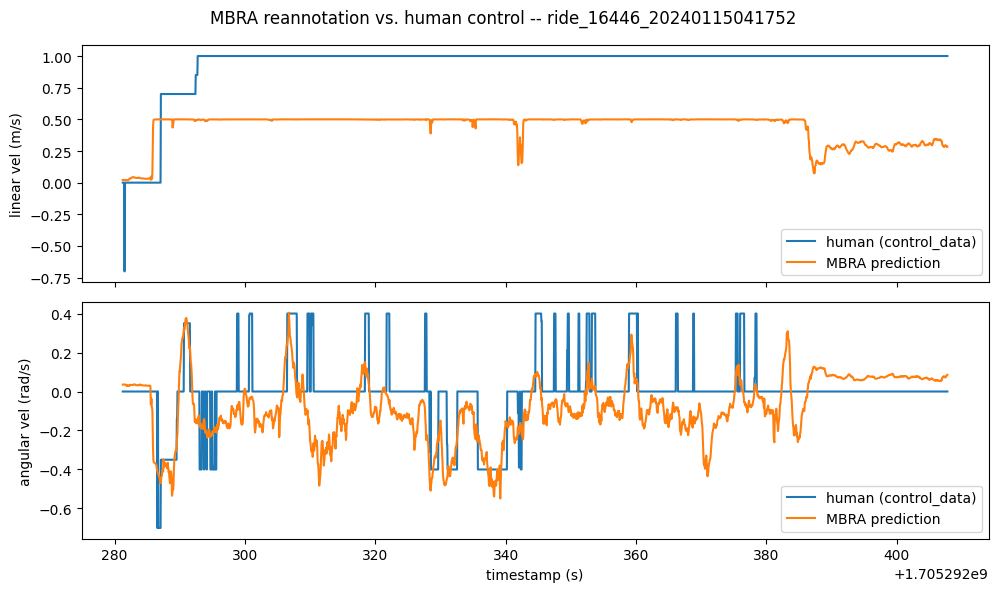

In [ ]:
import matplotlib.pyplot as plt

sample_ride = selected_ride_ids[0]
df = results_by_ride[sample_ride]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(df["timestamp"], df["orig_linear_vel_mps"], label="human (control_data)")
axes[0].plot(df["timestamp"], df["mbra_linear_vel_mps"], label="MBRA prediction")
axes[0].set_ylabel("linear vel (m/s)")
axes[0].legend()

axes[1].plot(df["timestamp"], df["orig_angular_vel_radps"], label="human (control_data)")
axes[1].plot(df["timestamp"], df["mbra_angular_vel_radps"], label="MBRA prediction")
axes[1].set_ylabel("angular vel (rad/s)")
axes[1].set_xlabel("timestamp (s)")
axes[1].legend()

fig.suptitle(f"MBRA reannotation vs. human control -- {sample_ride}")
plt.tight_layout()
plt.show()